In [ ]:
%cd Negation

/home/amirhossein.hajimohammadrezaie/ECOR_extended/Negation


In [2]:
from diffusers import DiffusionPipeline
import clip
import torch
import numpy as np
import pandas as pd
import ast
from transformers import CLIPTokenizer
import math
from torch.utils.data import Dataset, DataLoader, default_collate
from tqdm import tqdm
import matplotlib.pyplot as plt
from PIL import Image
import cv2
from torchvision import transforms
import torch.nn.functional as F
from transformers import AutoModelForCausalLM, AutoTokenizer
import torch.nn as nn
import seaborn as sns
import os

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model, preprocess = clip.load("ViT-B/32", device=device)
preprocess = transforms.Compose([transforms.Resize((224, 224), transforms.InterpolationMode.BICUBIC, antialias=True)] + preprocess.transforms)
model.eval()
model = model.to(torch.float32)
batch_size = 128

for param in model.parameters():
    param.requires_grad = False


llm_path = "mistral-7B-sft-Negation/checkpoint-426"
llm_tokenizer = AutoTokenizer.from_pretrained(llm_path)
if llm_tokenizer.pad_token is None:
    llm_tokenizer.pad_token = llm_tokenizer.eos_token

llm = AutoModelForCausalLM.from_pretrained(
                    llm_path,
                    torch_dtype=torch.bfloat16,
                    device_map="auto"
    )

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

In [ ]:
class ModifiedTextEncoder(nn.Module):

    def __init__(self, text_encoder, tokenizer, llm, llm_tokenizer):
        super().__init__()

        self.text_encoder = text_encoder
        self.tokenizer = tokenizer
        self.llm = llm
        self.llm_tokenizer = llm_tokenizer
        self.THRESHOLD = 0.95
    
    def forward(self, texts: list):

        with torch.no_grad():
            inputs = llm_tokenizer.apply_chat_template(
                [[{'role': 'user', 'content': text}] for text in texts],
                add_generation_prompt=True,
                tokenize=True,
                return_dict=True,
                return_tensors="pt",
                padding='max_length',
                max_length=128,
                truncation=True,
            ).to(llm.device)

            outputs = llm.generate(**inputs, max_new_tokens=128)
            outputs = llm_tokenizer.batch_decode(outputs[:, inputs["input_ids"].shape[-1]:], skip_special_tokens=True)

            batch_aff_texts = [output.split('### Negative Part')[0].split('### Positive Part')[1].strip() if '### Positive Part' in output else "This is a photo" for output in outputs]
            batch_aff_texts = [text if text else "This is a photo" for text in batch_aff_texts]
            
            batch_not_texts = ["A photo of a " + output.split('### Negative Part')[1].strip() if '### Negative Part' in output else "" for output in outputs]


        
        batch_aff_texts_tok = self.tokenizer(batch_aff_texts, truncate=True).to(device)
        batch_not_texts_tok = self.tokenizer(batch_not_texts, truncate=True).to(device)
        
        batch_aff_texts_emb = F.normalize(self.text_encoder(**batch_aff_texts_tok), dim=-1) # a : B x d
        batch_not_texts_emb = F.normalize(self.text_encoder(**batch_not_texts_tok), dim=-1) # n : B x d
        alpha = math.acos(self.THRESHOLD) 
        a_T_n = torch.sum(batch_aff_texts_emb * batch_not_texts_emb, dim=-1) # cos(theta) : B,
        theta = torch.acos(a_T_n) # Theta : B,
        mask = theta < 2*alpha

        delta = alpha + theta/2.
        batch_texts_emb = torch.cos(delta)[:, None] * batch_not_texts_emb + (torch.sin(delta)/torch.sin(theta))[:, None] * (batch_aff_texts_emb - a_T_n[:, None]*batch_not_texts_emb)        

  0%|          | 0/50 [00:00<?, ?it/s]

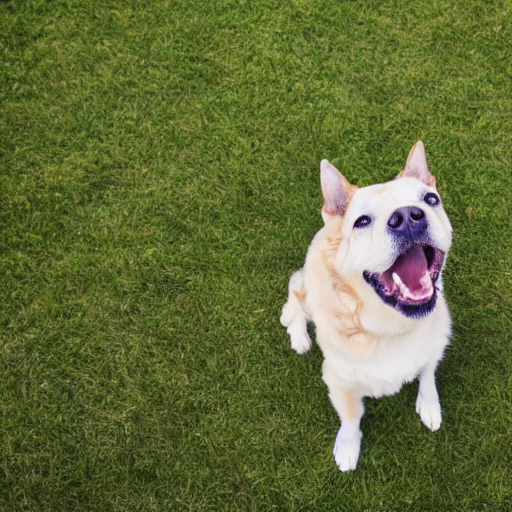

In [3]:
outputs = pipeline("A photo of a dog but not on grass")
outputs.images[0]

In [13]:
pipeline

StableDiffusionPipeline {
  "_class_name": "StableDiffusionPipeline",
  "_diffusers_version": "0.35.1",
  "_name_or_path": "stable-diffusion-v1-5/stable-diffusion-v1-5",
  "feature_extractor": [
    "transformers",
    "CLIPImageProcessor"
  ],
  "image_encoder": [
    null,
    null
  ],
  "requires_safety_checker": true,
  "safety_checker": [
    "stable_diffusion",
    "StableDiffusionSafetyChecker"
  ],
  "scheduler": [
    "diffusers",
    "PNDMScheduler"
  ],
  "text_encoder": [
    "transformers",
    "CLIPTextModel"
  ],
  "tokenizer": [
    "transformers",
    "CLIPTokenizer"
  ],
  "unet": [
    "diffusers",
    "UNet2DConditionModel"
  ],
  "vae": [
    "diffusers",
    "AutoencoderKL"
  ]
}